In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load processed data
crypto_df = pd.read_csv("../Data/processed/crypto_prices_processed.csv")
crypto_df["Date"] = pd.to_datetime(crypto_df["Date"])

crypto_df.head()

,Date,coin,Open,High,Low,Close,Volume,daily_return,cumulative_return
0,2020-01-01,ADA,0.032832,0.033813,0.032704,0.033458,22948374,NaN,NaN
1,2020-01-02,ADA,0.033474,0.033507,0.032448,0.032751,20843934,-0.021131,-0.021131
2,2020-01-03,ADA,0.032748,0.034427,0.032491,0.034180,30162644,0.043632,0.021579
3,2020-01-04,ADA,0.034191,0.034685,0.033872,0.034595,29535781,0.012142,0.033983
4,2020-01-05,ADA,0.034574,0.035356,0.034545,0.034721,21479178,0.003642,0.037749


In [3]:
# returns pivot table
returns_pivot = crypto_df.pivot(index="Date", columns="coin", values="daily_return")
returns_pivot.head()

coin,ADA,BNB,BTC,DOGE,DOT,ETH,LTC,SOL,XRP
Date,,,,,,,,,
2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-02,-0.021131,-0.048365,-0.029819,-0.011805,NaN,-0.025931,-0.052233,NaN,-0.024000
2020-01-03,0.043632,0.048625,0.051452,0.067695,NaN,0.053069,0.065102,NaN,0.029132
2020-01-04,0.012142,0.016915,0.008955,0.044755,NaN,0.006690,0.021479,NaN,0.004310
2020-01-05,0.003642,0.015802,0.000089,0.079429,NaN,0.008939,0.005230,NaN,0.006082


In [4]:
# Remove missing values
returns_pivot = returns_pivot.dropna()
returns_pivot.shape

(2044, 9)

In [5]:
# Annual returns and covariance
annual_returns = returns_pivot.mean() * 252
cov_matrix = returns_pivot.cov() * 252

annual_returns

coin
ADA     0.415375
BNB     0.640499
BTC     0.338825
DOGE    1.170226
DOT     0.272070
ETH     0.418735
LTC     0.246778
SOL     0.887440
XRP     0.567589
dtype: float64

In [6]:
# Simulation parameters
num_portfolios = 10000
coins = annual_returns.index.tolist()
num_assets = len(coins)

In [7]:
# Monte Carlo simulation
results = []
weights_list = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights = weights / np.sum(weights)
    
    portfolio_return = np.dot(weights, annual_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = portfolio_return / portfolio_volatility
    
    results.append([portfolio_return, portfolio_volatility, sharpe_ratio])
    weights_list.append(weights)

In [8]:
# Results DataFrame
results_df = pd.DataFrame(results, columns=["return", "volatility", "sharpe_ratio"])

weights_df = pd.DataFrame(weights_list, columns=coins)

portfolio_df = pd.concat([results_df, weights_df], axis=1)

portfolio_df.head()

,return,volatility,sharpe_ratio,ADA,BNB,BTC,DOGE,DOT,ETH,LTC,SOL,XRP
0,0.569918,0.670029,0.850587,0.104541,0.087607,0.160646,0.186659,0.094762,0.069273,0.135845,0.056314,0.104352
1,0.584450,0.664806,0.879130,0.130511,0.129474,0.037962,0.112199,0.117345,0.112942,0.099817,0.162164,0.097587
2,0.512757,0.646220,0.793471,0.059815,0.130265,0.102455,0.121622,0.178194,0.083051,0.195112,0.070454,0.059032
3,0.518503,0.630458,0.822423,0.054832,0.158665,0.122255,0.016029,0.190205,0.082174,0.045412,0.153226,0.177203
4,0.540111,0.649083,0.832114,0.025251,0.080882,0.121979,0.141398,0.121377,0.144966,0.148298,0.056853,0.158996


In [9]:
# Max sharpe ratio portfolio
max_sharpe_portfolio = portfolio_df.loc[portfolio_df["sharpe_ratio"].idxmax()]
max_sharpe_portfolio

return          0.722686
volatility      0.687639
sharpe_ratio    1.050967
ADA             0.038259
BNB             0.324173
BTC             0.002924
DOGE            0.120215
DOT             0.013974
ETH             0.002265
LTC             0.091548
SOL             0.310596
XRP             0.096045
Name: 9953, dtype: float64

In [10]:
# Min volatility portfolio
min_vol_portfolio = portfolio_df.loc[portfolio_df["volatility"].idxmin()]
min_vol_portfolio

return          0.457938
volatility      0.562560
sharpe_ratio    0.814025
ADA             0.031614
BNB             0.216112
BTC             0.262887
DOGE            0.031202
DOT             0.079221
ETH             0.255000
LTC             0.062750
SOL             0.007003
XRP             0.054209
Name: 7552, dtype: float64

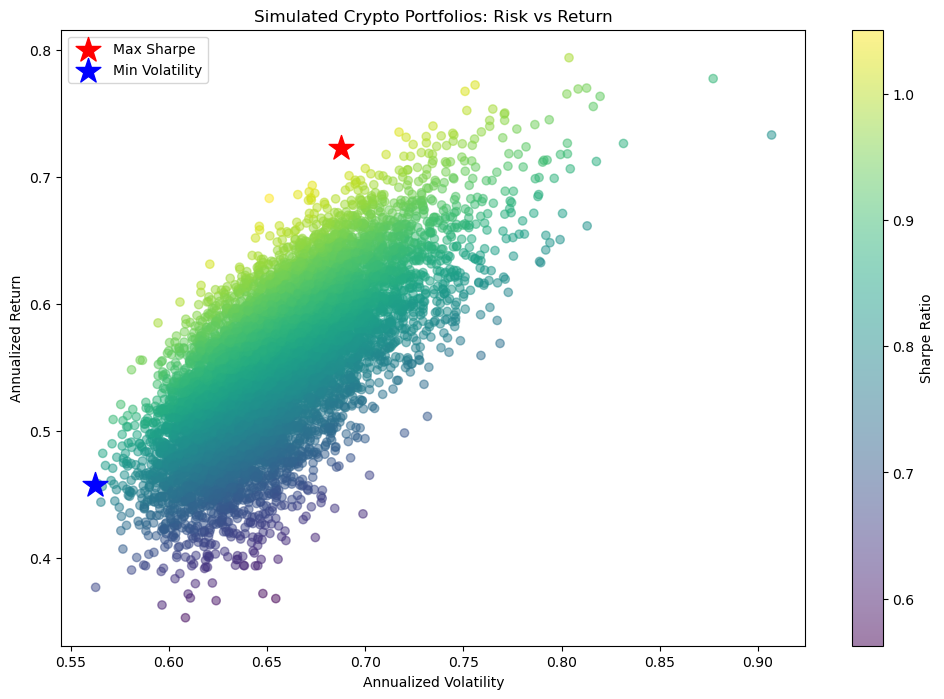

In [11]:
# Plot portfolio simulations
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    portfolio_df["volatility"],
    portfolio_df["return"],
    c=portfolio_df["sharpe_ratio"],
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(scatter, label="Sharpe Ratio")

plt.scatter(
    max_sharpe_portfolio["volatility"],
    max_sharpe_portfolio["return"],
    color="red",
    marker="*",
    s=350,
    label="Max Sharpe"
)

plt.scatter(
    min_vol_portfolio["volatility"],
    min_vol_portfolio["return"],
    color="blue",
    marker="*",
    s=350,
    label="Min Volatility"
)

plt.title("Simulated Crypto Portfolios: Risk vs Return")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.show()

In [12]:
# Max sharpe weights
max_sharpe_weights = max_sharpe_portfolio[coins].sort_values(ascending=False)
max_sharpe_weights

BNB     0.324173
SOL     0.310596
DOGE    0.120215
XRP     0.096045
LTC     0.091548
ADA     0.038259
DOT     0.013974
BTC     0.002924
ETH     0.002265
Name: 9953, dtype: float64

### The maximum Sharpe portfolio prioritised cryptocurrencies that delivered the best historical return relative to volatility. In this simulation, BNB and SOL dominated the optimal allocation, while BTC remained present as a stabilising major asset.

In [13]:
# Min volatility weights
min_vol_weights = min_vol_portfolio[coins].sort_values(ascending=False)
min_vol_weights

BTC     0.262887
ETH     0.255000
BNB     0.216112
DOT     0.079221
LTC     0.062750
XRP     0.054209
ADA     0.031614
DOGE    0.031202
SOL     0.007003
Name: 7552, dtype: float64

### The minimum volatility portfolio was much more concentrated in Bitcoin and Litecoin, suggesting that these assets offered the most stabilising effect within the selected universe. In contrast, highly volatile coins such as DOGE received minimal allocation in a low-risk strategy.

In [14]:
# Calculate percentage
(max_sharpe_weights * 100).round(2)
(min_vol_weights * 100).round(2)

BTC     26.29
ETH     25.50
BNB     21.61
DOT      7.92
LTC      6.27
XRP      5.42
ADA      3.16
DOGE     3.12
SOL      0.70
Name: 7552, dtype: float64

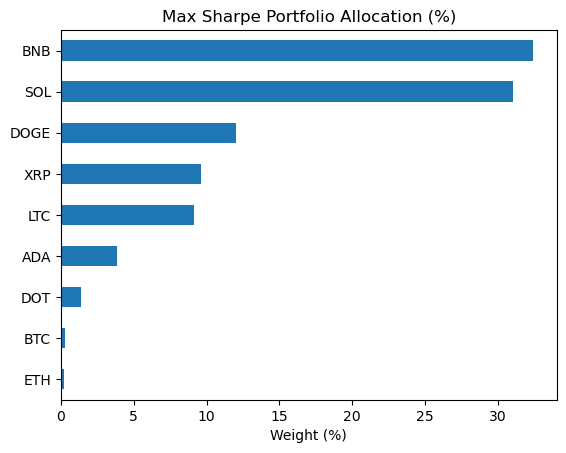

In [15]:
# Max sharpe allocation
(max_sharpe_weights * 100).sort_values().plot(kind="barh", title="Max Sharpe Portfolio Allocation (%)")
plt.xlabel("Weight (%)")
plt.show()

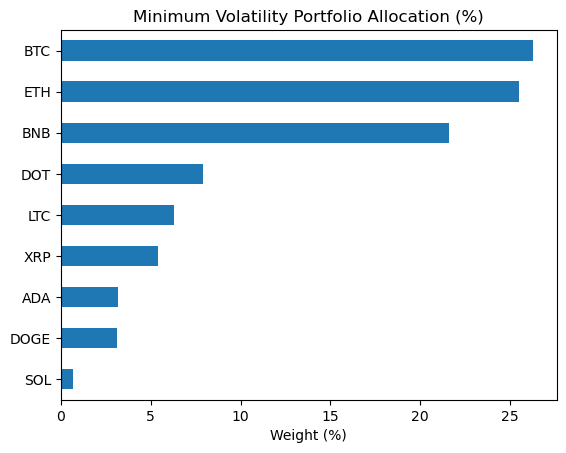

In [16]:
# Min volatility allocation
(min_vol_weights * 100).sort_values().plot(kind="barh", title="Minimum Volatility Portfolio Allocation (%)")
plt.xlabel("Weight (%)")
plt.show()

In [17]:
# Dataset for dashboard
portfolio_df.to_csv("../Data/processed/portfolio_simulations.csv", index=False)
max_sharpe_portfolio.to_frame().T.to_csv("../Data/processed/max_sharpe_portfolio.csv", index=False)
min_vol_portfolio.to_frame().T.to_csv("../Data/processed/min_volatility_portfolio.csv", index=False)

In [19]:
# Coin-level annualized metrics for dashboard summary
annual_returns = returns_pivot.mean() * 252
volatility = returns_pivot.std() * np.sqrt(252)
sharpe_ratio = annual_returns / volatility

# Max drawdown from processed dataset
crypto_df["cum_max"] = crypto_df.groupby("coin")["Close"].cummax()
crypto_df["drawdown"] = (crypto_df["Close"] / crypto_df["cum_max"]) - 1
max_drawdown = crypto_df.groupby("coin")["drawdown"].min()

In [20]:
# single summary table per coin
summary_df = pd.DataFrame({
    "annual_return": annual_returns,
    "annual_volatility": volatility,
    "sharpe_ratio": sharpe_ratio,
    "max_drawdown": max_drawdown
}).reset_index()

summary_df

summary_df.to_csv("../Data/processed/crypto_summary_metrics.csv", index=False)

# Interpretation 
## Max Sharpe portfolio insight
The maximum Sharpe portfolio represents the allocation that achieved the best historical risk-adjusted return among the simulated portfolios. This means it offered the highest return relative to the level of volatility taken.

## Minimum volatility portfolio insight
The minimum volatility portfolio represents the allocation that minimised overall portfolio risk. While it may not deliver the highest return, it provides a more conservative alternative for investors prioritising stability.

## Diversification insight
Comparing the optimal portfolios helps illustrate how diversification can improve portfolio behaviour relative to holding a single cryptocurrency, such as Bitcoin.